## 高级索引和索引技巧
NumPy 提供的索引功能比普通的 Python 序列更多。除了之前看到的整数和切片索引之外，数组还可以通过整数数组和布尔数组进行索引。

### 使用索引数组进行索引

In [3]:
import numpy as np

# 生成0-11的12个整数的平方数（0², 1², 2², ..., 11²），得到一维数组 a
a = np.arange(12)**2  
# a = [0, 1, 4, 9, 16, 25, 36, 49, 64, 81, 100, 121]
print (a)

# 定义一个索引数组 i，包含 5 个整数（其中 1 重复出现）
i = np.array([1, 1, 3, 8, 5])  

# 使用花式索引：取出 a 中索引位置为 i 的元素（允许重复索引）
print (a[i])  
# 结果：a[1]=1, a[1]=1, a[3]=9, a[8]=64, a[5]=25 → [1, 1, 9, 64, 25]

# 定义一个二维索引数组 j（形状 2×2）
j = np.array([[3, 4], [9, 7]])  

# 使用花式索引：返回与 j 形状相同的数组，每个元素是对应位置索引取自 a 的值
print (a[j])
# 结果：[[a[3]=9, a[4]=16],
#        [a[9]=81, a[7]=49]]
# 形状保持 (2,2)

[  0   1   4   9  16  25  36  49  64  81 100 121]
[ 1  1  9 64 25]
[[ 9 16]
 [81 49]]


当索引数组a是多维的时，单个索引数组指向数组的第一维a。以下示例通过使用调色板将标签图像转换为彩色图像来演示这种行为。

In [4]:
palette = np.array([[0, 0, 0],         # black
                    [255, 0, 0],       # red
                    [0, 255, 0],       # green
                    [0, 0, 255],       # blue
                    [255, 255, 255]])  # white
image = np.array([[0, 1, 2, 0],  # each value corresponds to a color in the palette
                  [0, 3, 4, 0]])
palette[image]  # the (2, 4, 3) color image


array([[[  0,   0,   0],
        [255,   0,   0],
        [  0, 255,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0, 255],
        [255, 255, 255],
        [  0,   0,   0]]])

我们还可以给出多个维度的索引。每个维度的索引数组必须具有相同的形状。

In [9]:
a = np.arange(12).reshape(3, 4)
print (a)
print ('-'*100)
# 定义行索引数组 i：形状 (2,2)，用于指定取哪些行
i = np.array([[0, 1],  # indices for the first dim of `a`
              [1, 2]])
# 定义列索引数组 j：形状 (2,2)，用于指定取哪些列
j = np.array([[2, 1],  # indices for the second dim
              [3, 3]])
# 花式索引：同时使用 i 和 j，它们必须形状相同
# 结果数组的每个元素取自 a[i[row,col], j[row,col]]
# 即 (i[0,0],j[0,0]) -> (0,2) -> a[0,2]=2
#    (i[0,1],j[0,1]) -> (1,1) -> a[1,1]=5
#    (i[1,0],j[1,0]) -> (1,3) -> a[1,3]=7
#    (i[1,1],j[1,1]) -> (2,3) -> a[2,3]=11
print (a[i, j])  # i and j must have equal shape
print ('-'*100)
# 行索引使用 i（形状 2x2），列索引固定为 2（标量，会被广播）
# 结果形状与 i 相同，每个元素为 a[i[row,col], 2]
print (a[i, 2])
print ('-'*100)
# 行索引使用全部行（:），列索引使用 j（形状 2x2）
# 结果形状为 (a.shape[0], j.shape[0], j.shape[1]) = (3, 2, 2)
# 即每个行位置，取出 j 指定的列元素
print (a[:, j])



[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
----------------------------------------------------------------------------------------------------
[[ 2  5]
 [ 7 11]]
----------------------------------------------------------------------------------------------------
[[ 2  6]
 [ 6 10]]
----------------------------------------------------------------------------------------------------
[[[ 2  1]
  [ 3  3]]

 [[ 6  5]
  [ 7  7]]

 [[10  9]
  [11 11]]]


### 布尔索引
我们可以通过一个布尔数组来索引目标数组。

布尔索引通过布尔运算（如：比较运算符）来获取符合指定条件的元素的数组。

以下实例获取大于 5 的元素：

In [10]:
import numpy as np 
 
x = np.array([[  0,  1,  2],[  3,  4,  5],[  6,  7,  8],[  9,  10,  11]])  
print ('我们的数组是：')
print (x)
print ('\n')
# 现在我们会打印出大于 5 的元素  
print  ('大于 5 的元素是：')
print (x[x >  5])

我们的数组是：
[[ 0  1  2]
 [ 3  4  5]
 [ 6  7  8]
 [ 9 10 11]]


大于 5 的元素是：
[ 6  7  8  9 10 11]


当我们使用整数索引数组来索引数组时，我们实际上是提供了一个索引列表供选择。而使用布尔索引则不同；我们需要明确地选择数组中哪些元素需要，哪些元素不需要。

对于布尔索引来说，最自然的方法是使用与原始数组形状相同的布尔数组：

In [11]:
a = np.arange(12).reshape(3, 4)
b = a > 4
print (b)  # `b` is a boolean with `a`'s shape
print (a[b])  # 1d array with the selected elements

[[False False False False]
 [False  True  True  True]
 [ True  True  True  True]]
[ 5  6  7  8  9 10 11]


您可以参考以下示例，了解如何使用布尔索引生成**曼德勃罗集**的图像：

/home/dll/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


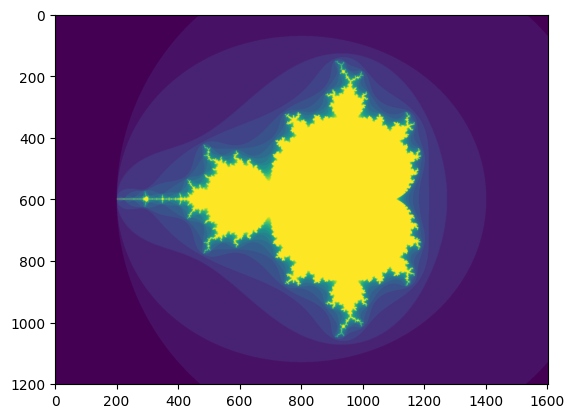

In [12]:
import numpy as np
import matplotlib.pyplot as plt
def mandelbrot(h, w, maxit=20, r=2):
    """Returns an image of the Mandelbrot fractal of size (h,w)."""
    x = np.linspace(-2.5, 1.5, 4*h+1)
    y = np.linspace(-1.5, 1.5, 3*w+1)
    A, B = np.meshgrid(x, y)
    C = A + B*1j
    z = np.zeros_like(C)
    divtime = maxit + np.zeros(z.shape, dtype=np.int_)
    for i in range(maxit):
        z = z**2 + C
        diverge = abs(z) > r                    # who is diverging
        div_now = diverge & (divtime == maxit)  # who is diverging now
        divtime[div_now] = i                    # note when
        z[diverge] = r                          # avoid diverging too much
    return divtime
plt.clf()
plt.imshow(mandelbrot(400, 400))

带缩放的**曼德勃罗集**

正在计算范围: x∈[-2.500000, 1.500000], y∈[-1.500000, 1.500000]


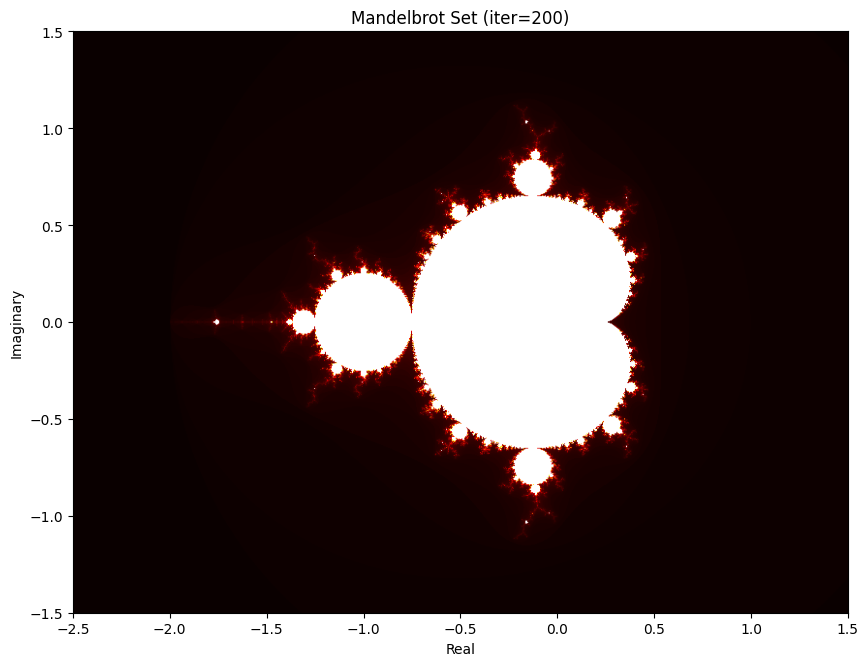

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def mandelbrot(xmin, xmax, ymin, ymax, width, height, maxit=100, r=2):
    """
    计算指定矩形区域的曼德勃罗集发散时间矩阵
    参数：
        xmin, xmax: 实部范围
        ymin, ymax: 虚部范围
        width, height: 输出图像的宽度和高度（像素）
        maxit: 最大迭代次数
        r: 发散半径阈值
    返回：
        divtime: 形状为 (height, width) 的整型数组，表示首次发散时的迭代次数
    """
    x = np.linspace(xmin, xmax, width)
    y = np.linspace(ymin, ymax, height)
    A, B = np.meshgrid(x, y)
    C = A + B * 1j
    z = np.zeros_like(C)
    divtime = maxit * np.ones(z.shape, dtype=int)
    for i in range(maxit):
        z = z * z + C
        diverge = np.abs(z) > r
        div_now = diverge & (divtime == maxit)
        divtime[div_now] = i
        z[diverge] = r
    return divtime

# 全局变量，存储当前视图范围和图像对象
current_xmin, current_xmax = -2.5, 1.5
current_ymin, current_ymax = -1.5, 1.5
img_width, img_height = 800, 800  # 计算分辨率（越高越精细但慢）
max_iter = 200                     # 最大迭代次数，可随缩放增大而增大
img = None                         # 用于存储图像对象

def update_image():
    """重新计算并更新图像"""
    global img, current_xmin, current_xmax, current_ymin, current_ymax
    print(f"正在计算范围: x∈[{current_xmin:.6f}, {current_xmax:.6f}], y∈[{current_ymin:.6f}, {current_ymax:.6f}]")
    divtime = mandelbrot(current_xmin, current_xmax, current_ymin, current_ymax,
                         img_width, img_height, max_iter)
    if img is None:
        img = ax.imshow(divtime, cmap='hot', extent=[current_xmin, current_xmax, current_ymin, current_ymax])
    else:
        img.set_data(divtime)
        img.set_extent([current_xmin, current_xmax, current_ymin, current_ymax])
    ax.set_title(f"Mandelbrot Set (iter={max_iter})")
    plt.draw()

def on_click(event):
    """鼠标事件：左键放大，右键缩小"""
    global current_xmin, current_xmax, current_ymin, current_ymax, max_iter
    if event.inaxes != ax:
        return
    # 获取点击的坐标
    cx, cy = event.xdata, event.ydata
    if cx is None or cy is None:
        return
    # 当前区域宽度和高度
    width = current_xmax - current_xmin
    height = current_ymax - current_ymin
    if event.button == 1:        # 左键：放大2倍
        scale_factor = 0.5
        # 增加迭代次数以获得更精细的细节（可选）
        max_iter = min(max_iter * 2, 2000)   # 上限2000
    elif event.button == 3:      # 右键：缩小2倍
        scale_factor = 2.0
        max_iter = max(max_iter // 2, 50)    # 下限50
    else:
        return
    new_width = width * scale_factor
    new_height = height * scale_factor
    current_xmin = cx - new_width / 2
    current_xmax = cx + new_width / 2
    current_ymin = cy - new_height / 2
    current_ymax = cy + new_height / 2
    update_image()

def on_key(event):
    """键盘控制：按 r 重置视图"""
    global current_xmin, current_xmax, current_ymin, current_ymax, max_iter
    if event.key == 'r':
        current_xmin, current_xmax = -2.5, 1.5
        current_ymin, current_ymax = -1.5, 1.5
        max_iter = 200
        update_image()
    elif event.key == 'q':   # 按 q 退出
        plt.close()

# 创建图形和坐标轴
plt.ion()               # 打开交互模式
fig, ax = plt.subplots(figsize=(10, 8))
ax.set_xlabel("Real")
ax.set_ylabel("Imaginary")
ax.set_title("Mandelbrot Set (Left click: zoom in, Right click: zoom out, R: reset)")

# 初始绘制
update_image()

# 绑定事件
fig.canvas.mpl_connect('button_press_event', on_click)
fig.canvas.mpl_connect('key_press_event', on_key)

plt.ioff()             # 关闭交互模式，显示窗口
plt.show()

第二种使用布尔值进行索引的方式更类似于整数索引；对于数组的每个维度，我们给出一个一维布尔数组来选择我们想要的切片：

In [15]:
a = np.arange(12).reshape(3, 4)
b1 = np.array([False, True, True])         # first dim selection
b2 = np.array([True, False, True, False])  # second dim selection
print (a)
print (a[b1, :])                                   # selecting rows
print (a[b1])                                      # same thing
print (a[:, b2])                                   # selecting columns
print (a[b1, b2])                                  # a weird thing to do

[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[ 4  5  6  7]
 [ 8  9 10 11]]
[[ 4  5  6  7]
 [ 8  9 10 11]]
[[ 0  2]
 [ 4  6]
 [ 8 10]]
[ 4 10]


### ix_() 函数
ix_函数可用于组合不同的向量，从而获得每个 n 元组的结果。例如，如果您想计算从向量 a、b 和 c 中取出的所有三元组的 a+b*c：


In [22]:
a = np.array([2, 3, 4, 5])
print (a)
b = np.array([8, 5, 4])
c = np.array([5, 4, 6, 8, 3])
# np.ix_() 将多个一维数组转换为用于广播的索引网格
# 返回的每个数组会增加维度，使得它们可以相互广播
ax, bx, cx = np.ix_(a, b, c)
print ('-'*20,'ax','-'*20)
print (ax)
print ('-'*20,'bx','-'*20)
print (bx)
print ('-'*20,'cx','-'*20)
print (cx)
print (ax.shape, bx.shape, cx.shape)

# 利用广播机制进行计算：ax + bx * cx
# 广播后三个数组形状均变为 (4,3,5)，逐元素运算
# result[i,j,k] = a[i] + b[j] * c[k]
result = ax + bx * cx
print ('-'*20,'result','-'*20)
print (result)
print ('-'*20,'result[3, 2, 4]','-'*20)
# 验证索引：取 result 中 i=3, j=2, k=4 的元素
print (result[3, 2, 4])
# 直接计算 a[3] + b[2] * c[4] 进行验证与上面结果一致
print ('-'*20,'a[3] + b[2] * c[4]','-'*20)
print (a[3] + b[2] * c[4])

[2 3 4 5]
-------------------- ax --------------------
[[[2]]

 [[3]]

 [[4]]

 [[5]]]
-------------------- bx --------------------
[[[8]
  [5]
  [4]]]
-------------------- cx --------------------
[[[5 4 6 8 3]]]
(4, 1, 1) (1, 3, 1) (1, 1, 5)
-------------------- result --------------------
[[[42 34 50 66 26]
  [27 22 32 42 17]
  [22 18 26 34 14]]

 [[43 35 51 67 27]
  [28 23 33 43 18]
  [23 19 27 35 15]]

 [[44 36 52 68 28]
  [29 24 34 44 19]
  [24 20 28 36 16]]

 [[45 37 53 69 29]
  [30 25 35 45 20]
  [25 21 29 37 17]]]
-------------------- result[3, 2, 4] --------------------
17
-------------------- a[3] + b[2] * c[4] --------------------
17
